In [9]:
import pandas as pd 
import numpy as np 
import warnings
warnings.filterwarnings('ignore')

In [10]:
voyage_lists = pd.read_csv('./data/cleaned_data/voyage_schedule.csv')
applications = pd.read_csv('./data/cleaned_data/applications.csv')
completions = pd.read_csv('./data/cleaned_data/completions.csv')
transactions = pd.read_csv('./data/cleaned_data/transactions.csv')

In [36]:
# Extract the list of unique voyages
voyage_list = voyage_lists["Name"].dropna().unique()

# Filter applications for users who have started at least one voyage
applications_active = applications[applications['No. Voyages Started'] > 0]

# Merge data on "Unique ID"
merged_df = applications_active.merge(transactions, on="Unique ID", suffixes=('_applications', '_transactions'))

# Merge with completions dataset
merged_df = merged_df.merge(completions, on="Unique ID", suffixes=('', '_completion'))

# Explode data based on 'Voyage (from Voyage Signups)' instead of 'What is your Voyage?'
if 'Voyage (from Voyage Signups)' in merged_df.columns:
    merged_df['Voyage (from Voyage Signups)'] = merged_df['Voyage (from Voyage Signups)'].astype(str).str.split(';')
    merged_df = merged_df.explode('Voyage (from Voyage Signups)')

# Replace voyage names with their corresponding start dates using voyage schedule
if 'Name' in voyage_lists.columns and 'Start Date' in voyage_lists.columns:
    voyage_start_date_mapping = voyage_lists.set_index('Name')['Start Date'].to_dict()
    merged_df['Voyage (from Voyage Signups)'] = merged_df['Voyage (from Voyage Signups)'].map(voyage_start_date_mapping)

# Save the updated merged dataset
updated_merged_df_path = "./data/cleaned_data/chingu_merged_df_with_start_dates.csv"
merged_df.to_csv(updated_merged_df_path, index=False)


In [37]:
merged_df.head()

,Unique ID,Timestamp,Subscription Status_applications,Subscription Status DT,Voyage Role,Gender,Goal,Source,Most Excited About,Country name (from Country),...,Completed Voyage?,Completion Status,Certificate Issue Date,What is your Tier?,"What is the name of the project? (If there isn't a name you can just write ""no name"")","What tech-stack did you use for your project? (ex. React, webpack, node.js, MongoDB, etc.)","On a scale of 0-10, how likely are you to recommend Chingu to a friend or colleagues?",Status (from Voyage Signups Link),Role (from Voyage Signups Link),Product_completion
0,56a8ef8425ff0595bd660065cae07793,2025-01-03 10:21:00,Active,2025-01-03,Scrum Master,FEMALE,GAIN EXPERIENCE,PERSONAL NETWORK,"2 - Having access to team project experiences,...",United Kingdom,...,Yes,Cert Issued,2025-02-23,Tier 3,Meal Planner,"React, TypeScript, Material UI, Emotion, Tailw...",10.0,Active,Scrum Master,Subscription - Junior Professional
1,0a534d132b4dcf8e3b3dad5d766cac4b,2025-01-03 09:37:00,Active,2025-01-03,Developer,FEMALE,ACCELERATE LEARNING,LinkedIn,"2 - Having access to team project experiences,...",United States,...,Yes,Cert Issued,2025-02-23,Tier 2,Platepal,"FontAwesome, HeadlessUI, React, React-Calendar...",10.0,Active,Developer,Subscription - Professional
2,0a534d132b4dcf8e3b3dad5d766cac4b,2025-01-03 09:37:00,Active,2025-01-03,Developer,FEMALE,ACCELERATE LEARNING,LinkedIn,"2 - Having access to team project experiences,...",United States,...,Yes,Cert Issued,2025-02-23,Tier 2,Platepal,"FontAwesome, HeadlessUI, React, React-Calendar...",10.0,Active,Developer,Subscription - Professional
3,9377c7a85233065fcab7834ef14ef7a8,2024-12-21 15:37:00,Active,2024-12-21,Developer,MALE,GAIN EXPERIENCE,OTHER_Other,1 - Being in a group of friendly coders who sh...,Greece,...,Yes,Cert Issued,2025-02-23,Tier 2,Project-Tier2-Menu-Scheduler,"1) Front-end [github pages] React, Vite, Tailw...",10.0,Active,Developer,Subscription - Junior Professional
4,9377c7a85233065fcab7834ef14ef7a8,2024-12-21 15:37:00,Active,2024-12-21,Developer,MALE,GAIN EXPERIENCE,OTHER_Other,1 - Being in a group of friendly coders who sh...,Greece,...,Yes,Cert Issued,2025-02-23,Tier 2,Project-Tier2-Menu-Scheduler,"1) Front-end [github pages] React, Vite, Tailw...",10.0,Active,Developer,Subscription - Junior Professional


In [18]:
merged_df.describe()


,Application Age in Days,Day-of-Week No,No. Voyages Started,Payment Amount,Transaction Fee,Net Payment,Refund Amount,Credits Purchased,"On a scale of 0-10, how likely are you to recommend Chingu to a friend or colleagues?"
count,1924.000000,1924.000000,1971.000000,1971.000000,1971.000000,1971.000000,1971.0,1971.0,1828.000000
mean,629.048857,3.747921,6.376459,4.701126,0.413988,4.287139,0.0,0.0,9.512582
std,288.630913,1.704166,4.970403,5.735265,0.234983,5.539669,0.0,0.0,1.184813
min,59.000000,1.000000,1.000000,0.000000,0.000000,-0.300000,0.0,0.0,3.000000
25%,437.000000,2.000000,2.000000,2.990000,0.300000,2.690000,0.0,0.0,10.000000
50%,643.000000,4.000000,4.000000,2.990000,0.390000,2.690000,0.0,0.0,10.000000
75%,839.000000,5.000000,10.000000,3.990000,0.430000,3.590000,0.0,0.0,10.000000
max,1974.000000,7.000000,16.000000,100.000000,3.200000,96.800000,0.0,0.0,10.000000


In [35]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1971 entries, 0 to 1970
Data columns (total 39 columns):
 #   Column                                                                                      Non-Null Count  Dtype  
---  ------                                                                                      --------------  -----  
 0   Unique ID                                                                                   1971 non-null   object 
 1   Timestamp                                                                                   1924 non-null   object 
 2   Subscription Status_applications                                                            1967 non-null   object 
 3   Subscription Status DT                                                                      1922 non-null   object 
 4   Voyage Role                                                                                 1971 non-null   object 
 5   Gender                                        

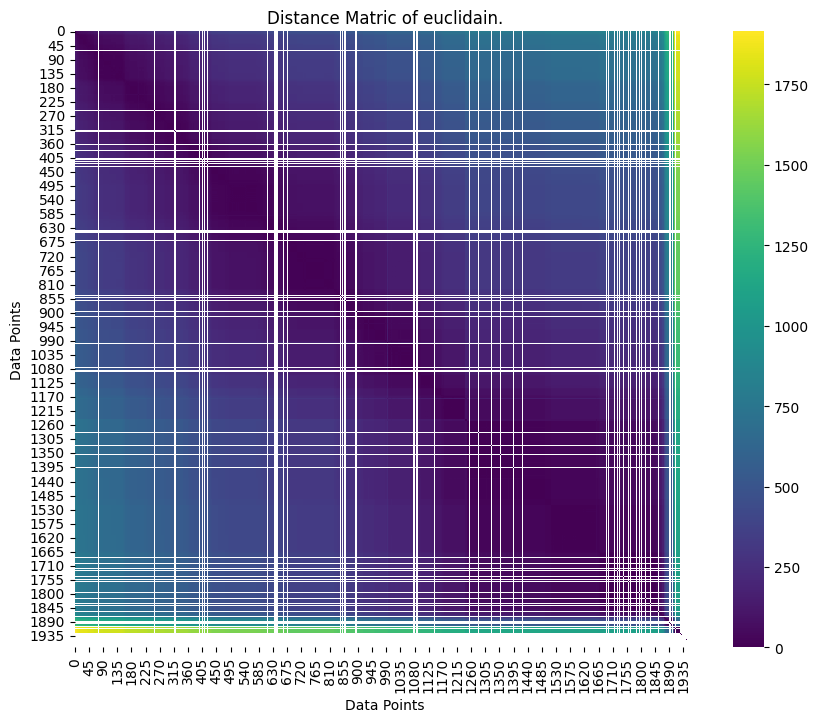

In [22]:
from scipy.spatial.distance import pdist, squareform
from sklearn.preprocessing import OneHotEncoder

categorical_fields = merged_df.select_dtypes(include=['object']).columns
encoder = OneHotEncoder(sparse_output = False, handle_unknown = 'ignore')
encoder_categorical = encoder.fit_transform(merged_df[categorical_fields])
# Convert to DataFrame
encoded_categorical_df = pd.DataFrame(encoder_categorical, 
                                      columns=encoder.get_feature_names_out(categorical_fields),
                                      index=merged_df.index)
# Combine numerical and encoded categorical data
final_encoded_df = pd.concat([merged_df.select_dtypes(include=['number']), encoded_categorical_df], axis=1)

# calculate distance matrix
distance_matrix = squareform(pdist(final_encoded_df, metric='euclidean'))
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(distance_matrix , cmap='viridis')
plt.title('Distance Matric of euclidain.')
plt.xlabel('Data Points')
plt.ylabel('Data Points')
plt.show()

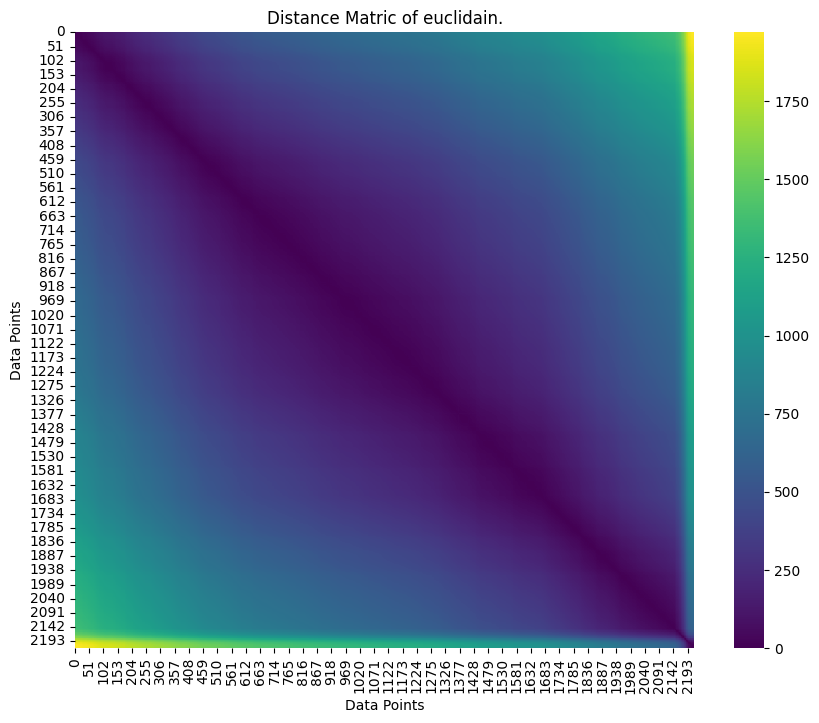

In [23]:
from scipy.spatial.distance import pdist, squareform
from sklearn.preprocessing import OneHotEncoder

if 'What is your Voyage?' in applications.columns:
    applications['What is your Voyage?'] = applications['What is your Voyage?'].astype(str).str.split(';')
    applications = applications.explode('What is your Voyage?')

applications_active= applications[applications['No. Voyages Started'] > 0]
categorical_fields = applications_active.select_dtypes(include=['object']).columns
encoder = OneHotEncoder(sparse_output = False, handle_unknown = 'ignore')
encoder_categorical = encoder.fit_transform(applications_active[categorical_fields])
# Convert to DataFrame
encoded_categorical_df = pd.DataFrame(encoder_categorical, 
                                      columns=encoder.get_feature_names_out(categorical_fields),
                                      index=applications_active.index)
# Combine numerical and encoded categorical data
final_encoded_df = pd.concat([applications_active.select_dtypes(include=['number']), encoded_categorical_df], axis=1)

# calculate distance matrix
distance_matrix = squareform(pdist(final_encoded_df, metric='euclidean'))
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(distance_matrix , cmap='viridis')
plt.title('Distance Matric of euclidain.')
plt.xlabel('Data Points')
plt.ylabel('Data Points')
plt.show()

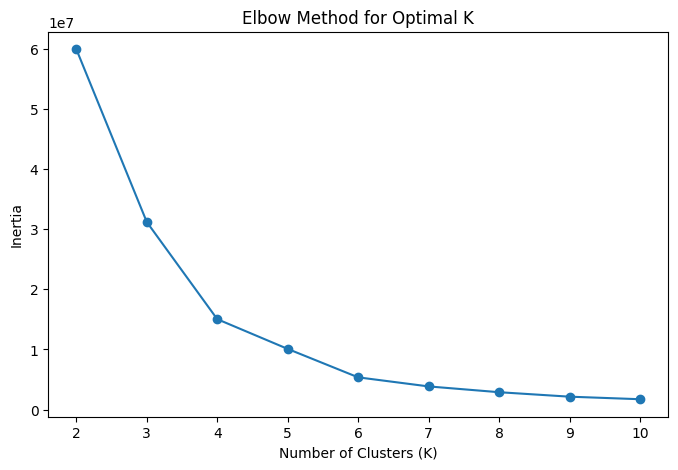

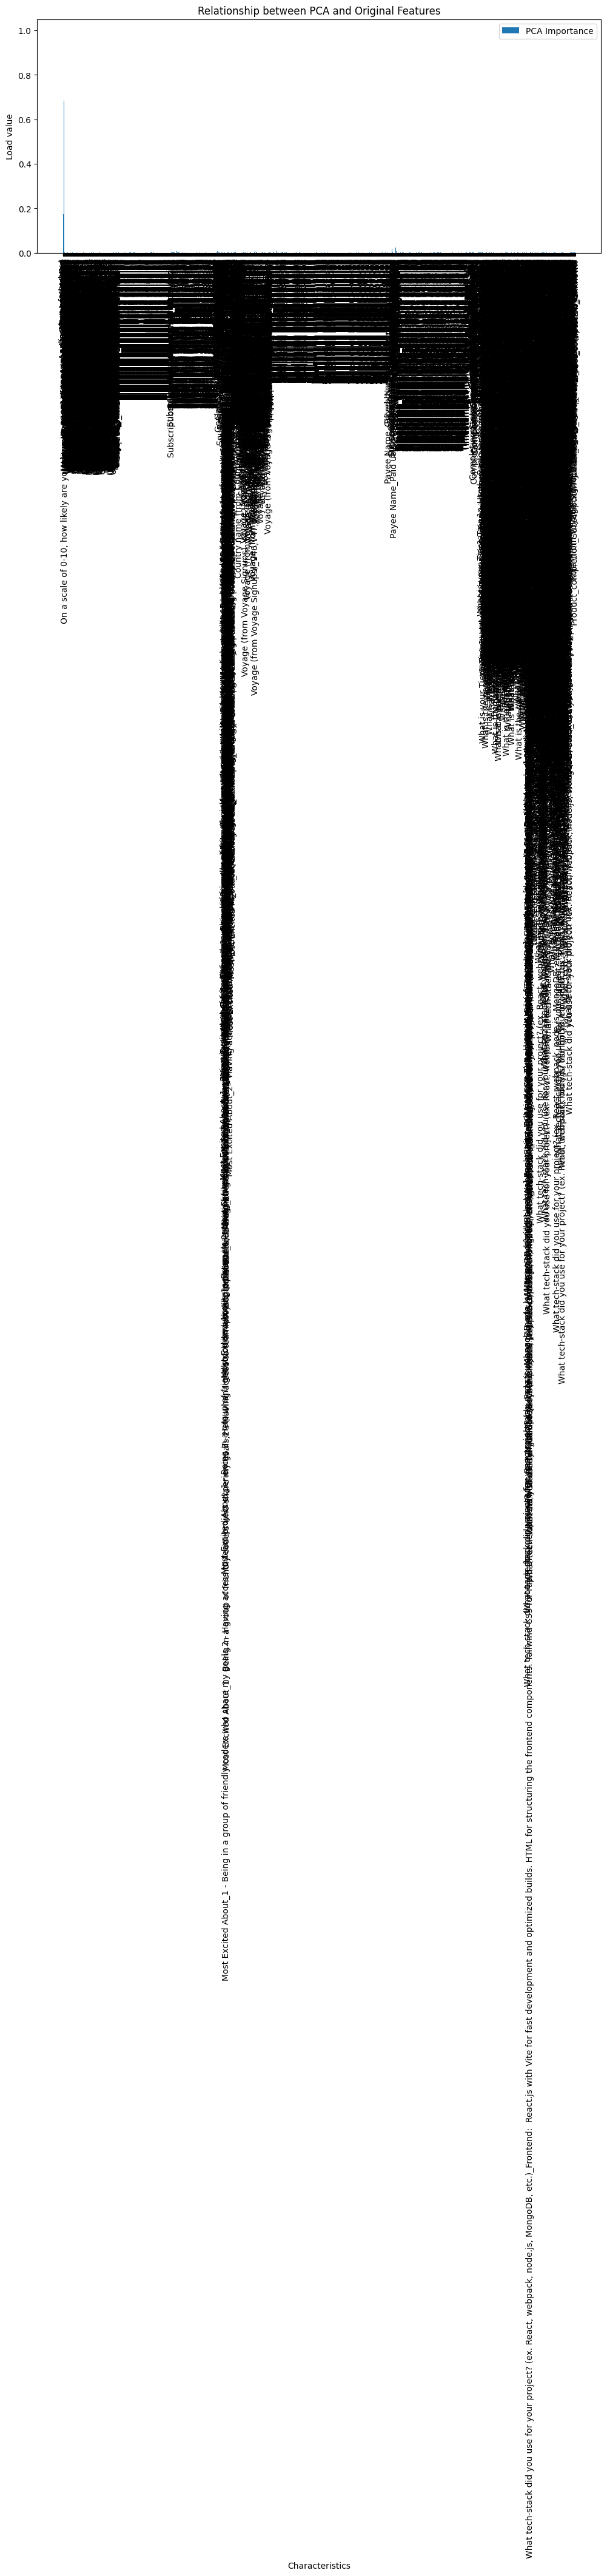

Top Features in PCA:
 Application Age in Days                       1.000071
Payment Amount                                0.708937
Net Payment                                   0.684795
No. Voyages Started                           0.174775
Product_SUBSCRIPTION - Junior Professional    0.025660
dtype: float64


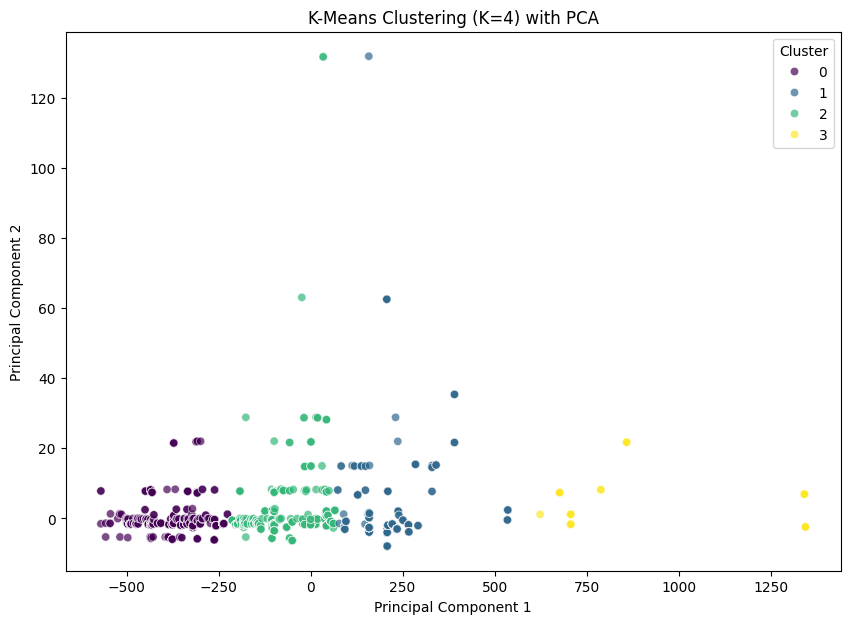

In [25]:
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Handle missing values in numerical columns by filling with the mean
num_imputer = SimpleImputer(strategy="mean")
numerical_data = merged_df.select_dtypes(include=['number'])
numerical_data_imputed = pd.DataFrame(num_imputer.fit_transform(numerical_data), 
                                      columns=numerical_data.columns, 
                                      index=merged_df.index)

# Handle missing values in categorical columns by filling with the mode (most frequent value)
cat_imputer = SimpleImputer(strategy="most_frequent")
categorical_fields = merged_df.select_dtypes(include=['object']).columns
categorical_data = merged_df[categorical_fields]
categorical_data_imputed = pd.DataFrame(cat_imputer.fit_transform(categorical_data), 
                                        columns=categorical_fields, 
                                        index=merged_df.index)

# Re-encode categorical columns after imputation
encoder_categorical = encoder.fit_transform(categorical_data_imputed)
encoded_categorical_df = pd.DataFrame(encoder_categorical, 
                                      columns=encoder.get_feature_names_out(categorical_fields),
                                      index=merged_df.index)

# Combine the cleaned numerical and categorical data
final_encoded_df = pd.concat([numerical_data_imputed, encoded_categorical_df], axis=1)

# Re-run K-Means clustering after handling NaN values
inertia = []
cluster_range = range(2, 11)  # Testing clusters from 2 to 10

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(final_encoded_df)
    inertia.append(kmeans.inertia_)

# Plot the Elbow method to determine optimal K
plt.figure(figsize=(8, 5))
plt.plot(cluster_range, inertia, marker='o', linestyle='-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.show()

# Choose an optimal number of clusters (K) based on the elbow method
optimal_k = 4  # Adjust based on the elbow point

# Apply K-Means clustering
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(final_encoded_df)

# Add cluster labels to the dataset
merged_df["Cluster"] = cluster_labels

# Use PCA to reduce dimensionality for visualization
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(final_encoded_df)

# Compute feature importance based on PCA
pca_components = np.abs(pca.components_[:2]).sum(axis=0)  # Sum absolute values for PC1 & PC2

# Create bar chart of feature importance
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(final_encoded_df.columns, pca_components, label='PCA Importance')
ax.set_xlabel('Characteristics')
ax.set_ylabel('Load value')
ax.set_title('Relationship between PCA and Original Features')
ax.legend()
ax.tick_params(axis='x', rotation=90)  # Rotate x-axis labels

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

# Get feature importance ranking
feature_importance_pca = pd.Series(pca_components, index=final_encoded_df.columns).sort_values(ascending=False)

print("Top Features in PCA:\n", feature_importance_pca.head(5))

# Create a scatter plot of the clusters
plt.figure(figsize=(10, 7))
sns.scatterplot(x=reduced_data[:, 0], y=reduced_data[:, 1], hue=cluster_labels, palette='viridis', alpha=0.7)
plt.title(f'K-Means Clustering (K={optimal_k}) with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title="Cluster")
plt.show()


In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
# Select only numerical columns for outlier detection
numerical_data = merged_df.select_dtypes(include=['number'])

# Apply Isolation Forest for outlier detection
iso_forest = IsolationForest(contamination=0.01, random_state=42)  # 1% expected outliers
outliers = iso_forest.fit_predict(numerical_data)

# Convert outlier labels (-1 = outlier, 1 = normal) to a boolean mask
outlier_mask = outliers == -1

# Mark outliers in the dataset
merged_df["Outlier"] = outlier_mask

# Create a version of the dataset without outliers
filtered_df = merged_df.copy()
filtered_df.loc[outlier_mask, numerical_data.columns] = np.nan  # Replace outliers with NaN

# Visualize before and after outlier removal using PCA
pca = PCA(n_components=2)
reduced_original = pca.fit_transform(numerical_data.fillna(numerical_data.mean()))  # Original data
reduced_filtered = pca.transform(filtered_df[numerical_data.columns].fillna(numerical_data.mean()))  # Replace NaN for visualization

plt.figure(figsize=(10, 6))
plt.scatter(reduced_original[:, 0], reduced_original[:, 1], label="Original Data", alpha=0.5)
plt.scatter(reduced_filtered[:, 0], reduced_filtered[:, 1], label="Filtered Data (No Outliers)", alpha=0.7, edgecolors='r')
plt.title("Outlier Detection & Removal with Isolation Forest")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()
